In [ ]:
'''
Here as in our finding we found that facultative sex (RME100 and SFE100) can lower both the Soma and Germ Mutation rate, we 
further want to investigate whether the amitosis or the sex that makes the difference

We simulated facultative sex with mitosis, also with a sexual frequency of every 100 generations, and compared the new results 
with our previous findings on facultative sex with amitosis.

'''

In [1]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [13]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_mean = []
    total_soma_mu_std = []

    total_germ_mu_mean = []
    total_germ_mu_std = []
    
    total_soma_genomic_mu_mean = []
    total_soma_genomic_mu_std = []    
    
    total_germ_genomic_mu_mean = []
    total_germ_genomic_mu_std = []  
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_mean = []
        soma_mu_std = []
        
        germ_mu_mean = []
        germ_mu_std = []        
        
        soma_genomic_mu_mean = []
        soma_genomic_mu_std = []
        
        germ_genomic_mu_mean = []
        germ_genomic_mu_std = []   
        
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_mean.extend(list(pd.Series(f.SomaMu_Mean,dtype=float)))
        soma_mu_std.extend(list(pd.Series(f.SomaMu_Std,dtype=float)))
        
        germ_mu_mean.extend(list(pd.Series(f.GermMu_Mean,dtype=float)))
        germ_mu_std.extend(list(pd.Series(f.GermMu_Std,dtype=float)))   
        
        soma_genomic_mu_mean.extend(list(pd.Series(f.SomaGenomicMu_Mean,dtype=float)))
        soma_genomic_mu_std.extend(list(pd.Series(f.SomaGenomicMu_Std,dtype=float)))
        
        germ_genomic_mu_mean.extend(list(pd.Series(f.GermGenomicMu_Mean,dtype=float)))
        germ_genomic_mu_std.extend(list(pd.Series(f.GermGenomicMu_Std,dtype=float)))        
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_mean.append(soma_mu_mean)
        total_soma_mu_std.append(soma_mu_std)  
        
        total_germ_mu_mean.append(germ_mu_mean)
        total_germ_mu_std.append(germ_mu_std)    

        
        total_soma_genomic_mu_mean.append(soma_genomic_mu_mean)
        total_soma_genomic_mu_std.append(soma_genomic_mu_std)  
        
        total_germ_genomic_mu_mean.append(germ_genomic_mu_mean)
        total_germ_genomic_mu_std.append(germ_genomic_mu_std) 
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_mean, total_soma_mu_std, \
total_germ_mu_mean, total_germ_mu_std, total_soma_genomic_mu_mean, total_soma_genomic_mu_std, \
total_germ_genomic_mu_mean, total_germ_genomic_mu_std

## Dele Only_N = 2K_RME100 with amitosis

In [14]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2. Eff = 0.9_Lower Mu = 0.002 and Upper Mu = 0.01\1. Dele Only\N2K")

In [15]:
og_fit_file = ['Fit_RME100_N2K_DeleOnly_UP01LW002_MuEvo_190910R2.csv']

og = get_data1(og_fit_file)

og_fit_mean =og[0]
og_fit_std = og[1]

og_sm_mu_mean = og[2]
og_sm_mu_std = og[3]

og_gm_mu_mean = og[4]
og_gm_mu_std = og[5]

og_sm_genomic_mu_mean = og[6]
og_sm_genomic_mu_std = og[7]

og_gm_genomic_mu_mean = og[8]
og_gm_genomic_mu_std = og[9]

In [16]:
print 'FS Amito MAC Mu', og_sm_mu_mean[0][-1]/(0.1/45/100), og_sm_mu_mean[0][-1]/(0.1/45/100)-1.98*og_sm_mu_std[0][-1]/10/(0.1/45/100), og_sm_mu_mean[0][-1]/(0.1/45/100)+1.98*og_sm_mu_std[0][-1]/10/(0.1/45/100)
print 'FS Amito MIC Mu', og_gm_mu_mean[0][-1]/(0.1/45/100), og_gm_mu_mean[0][-1]/(0.1/45/100)-1.98*og_gm_mu_std[0][-1]/10/(0.1/45/100), og_gm_mu_mean[0][-1]/(0.1/45/100)+1.98*og_gm_mu_std[0][-1]/10/(0.1/45/100)

FS Amito MAC Mu 0.128039459799 0.0860188389214 0.170060080677
FS Amito MIC Mu 0.165371406597 0.125807440932 0.204935372262


## Dele Only_N = 2K_RME100 with Mitosis

In [17]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2.2. Facultative Sex with Mito\1. Dele Only\N2K")

In [18]:
rv_fit_file = ['Fit_RME100_Mito_N2K_Dele_UP01LW002_MuEvo_191007R2.csv']

rv = get_data1(rv_fit_file)

rv_fit_mean =rv[0]
rv_fit_std = rv[1]

rv_sm_mu_mean = rv[2]
rv_sm_mu_std = rv[3]

rv_gm_mu_mean = rv[4]
rv_gm_mu_std = rv[5]

rv_sm_genomic_mu_mean = rv[6]
rv_sm_genomic_mu_std = rv[7]

rv_gm_genomic_mu_mean = rv[8]
rv_gm_genomic_mu_std = rv[9]

In [19]:
dele_og_sm_mu_mean = [og_sm_mu_mean[0][-1]/(0.1/45/100)]+[rv_sm_mu_mean[0][-1]/(0.1/45/100)]
dele_og_sm_mu_std = [og_sm_mu_std[0][-1]/(0.1/45/100)]+[rv_sm_mu_std[0][-1]/(0.1/45/100)]

dele_og_gm_mu_mean = [og_gm_mu_mean[0][-1]/(0.1/45/100)]+[rv_gm_mu_mean[0][-1]/(0.1/45/100)]
dele_og_gm_mu_std = [og_gm_mu_std[0][-1]/(0.1/45/100)]+[rv_gm_mu_std[0][-1]/(0.1/45/100)]

In [20]:
print 'FS Mito MAC Mu', rv_sm_mu_mean[0][-1]/(0.1/45/100), rv_sm_mu_mean[0][-1]/(0.1/45/100)-1.98*rv_sm_mu_std[0][-1]/10/(0.1/45/100), rv_sm_mu_mean[0][-1]/(0.1/45/100)+1.98*rv_sm_mu_std[0][-1]/10/(0.1/45/100)
print 'FS Mito MIC Mu', rv_gm_mu_mean[0][-1]/(0.1/45/100), rv_gm_mu_mean[0][-1]/(0.1/45/100)-1.98*rv_gm_mu_std[0][-1]/10/(0.1/45/100), rv_gm_mu_mean[0][-1]/(0.1/45/100)+1.98*rv_gm_mu_std[0][-1]/10/(0.1/45/100)

FS Mito MAC Mu 0.0470375956879 0.0381361333332 0.0559390580426
FS Mito MIC Mu 0.213192492495 0.151594476518 0.274790508471


In [21]:
def get_data2(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_bene_mean = []
    total_soma_mu_bene_std = []

    total_soma_mu_dele_mean = []
    total_soma_mu_dele_std = []
    
    total_germ_mu_bene_mean = []
    total_germ_mu_bene_std = []

    total_germ_mu_dele_mean = []
    total_germ_mu_dele_std = []  
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_bene_mean = []
        soma_mu_bene_std = []

        soma_mu_dele_mean = []
        soma_mu_dele_std = []
        
        germ_mu_bene_mean = []
        germ_mu_bene_std = []        
         
        germ_mu_dele_mean = []
        germ_mu_dele_std = []             
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_bene_mean.extend(list(pd.Series(f.SomaMu_Bene_Mean,dtype=float)))
        soma_mu_bene_std.extend(list(pd.Series(f.SomaMu_Bene_Std,dtype=float)))

        soma_mu_dele_mean.extend(list(pd.Series(f.SomaMu_Dele_Mean,dtype=float)))
        soma_mu_dele_std.extend(list(pd.Series(f.SomaMu_Dele_Std,dtype=float)))
        
        
        germ_mu_bene_mean.extend(list(pd.Series(f.GermMu_Bene_Mean,dtype=float)))
        germ_mu_bene_std.extend(list(pd.Series(f.GermMu_Bene_Std,dtype=float)))

        germ_mu_dele_mean.extend(list(pd.Series(f.GermMu_Dele_Mean,dtype=float)))
        germ_mu_dele_std.extend(list(pd.Series(f.GermMu_Dele_Std,dtype=float)))
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_bene_mean.append(soma_mu_bene_mean)
        total_soma_mu_bene_std.append(soma_mu_bene_std)  

        total_soma_mu_dele_mean.append(soma_mu_dele_mean)
        total_soma_mu_dele_std.append(soma_mu_dele_std)
        
        total_germ_mu_bene_mean.append(germ_mu_bene_mean)
        total_germ_mu_bene_std.append(germ_mu_bene_std)    

        total_germ_mu_dele_mean.append(germ_mu_dele_mean)
        total_germ_mu_dele_std.append(germ_mu_dele_std)
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_bene_mean, total_soma_mu_bene_std, \
total_soma_mu_dele_mean, total_soma_mu_dele_std, total_germ_mu_bene_mean, total_germ_mu_bene_std, \
total_germ_mu_dele_mean, total_germ_mu_dele_std

## 1% Bene_N = 2K_RME100  with amitosis

In [22]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2. Eff = 0.9_Lower Mu = 0.002 and Upper Mu = 0.01\2. 1% Bene\N2K\SP")

In [24]:
bene_og_fit_file = ['Fit_RME100_N2K_Bene01_UP01LW002_MuEvo_190910R2.csv']

bene_og = get_data2(bene_og_fit_file)

bene_og_fit_mean =bene_og[0]
bene_og_fit_std = bene_og[1]

bene_og_sm_mu_bene_mean = bene_og[2]
bene_og_sm_mu_bene_std = bene_og[3]

bene_og_sm_mu_dele_mean = bene_og[4]
bene_og_sm_mu_dele_std = bene_og[5]

bene_og_gm_mu_bene_mean = bene_og[6]
bene_og_gm_mu_bene_std = bene_og[7]

bene_og_gm_mu_dele_mean = bene_og[8]
bene_og_gm_mu_dele_std = bene_og[9]

## 1% Bene_N = 2K_RME100  with mitosis

In [25]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2.2. Facultative Sex with Mito\2. 1% Bene\N2K")

In [26]:
bene_rv_fit_file = ['Fit_RME100_Mito_N2K_Bene01_UP01LW002_MuEvo_191007R2.csv']

bene_rv = get_data2(bene_rv_fit_file)

bene_rv_fit_mean =bene_rv[0]
bene_rv_fit_std = bene_rv[1]

bene_rv_sm_mu_bene_mean = bene_rv[2]
bene_rv_sm_mu_bene_std = bene_rv[3]

bene_rv_sm_mu_dele_mean = bene_rv[4]
bene_rv_sm_mu_dele_std = bene_rv[5]

bene_rv_gm_mu_bene_mean = bene_rv[6]
bene_rv_gm_mu_bene_std = bene_rv[7]

bene_rv_gm_mu_dele_mean = bene_rv[8]
bene_rv_gm_mu_dele_std = bene_rv[9]

In [28]:
bene_og_sm_mu_mean = [bene_og_sm_mu_dele_mean[0][-1]/(0.1/45/100)]+[bene_rv_sm_mu_dele_mean[0][-1]/(0.1/45/100)]
bene_og_sm_mu_std = [bene_og_sm_mu_dele_std[0][-1]/(0.1/45/100)]+[bene_rv_sm_mu_dele_std[0][-1]/(0.1/45/100)]

bene_og_gm_mu_mean = [bene_og_gm_mu_dele_mean[0][-1]/(0.1/45/100)]+[bene_rv_gm_mu_dele_mean[0][-1]/(0.1/45/100)]
bene_og_gm_mu_std = [bene_og_gm_mu_dele_std[0][-1]/(0.1/45/100)]+[bene_rv_gm_mu_dele_std[0][-1]/(0.1/45/100)]

In [35]:
bene_og_gm_mu_mean

[1.0158498470759252, 0.75446137104705402]

In [30]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

In [31]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

c [0.25486792338329695, 0.16317557105543859]


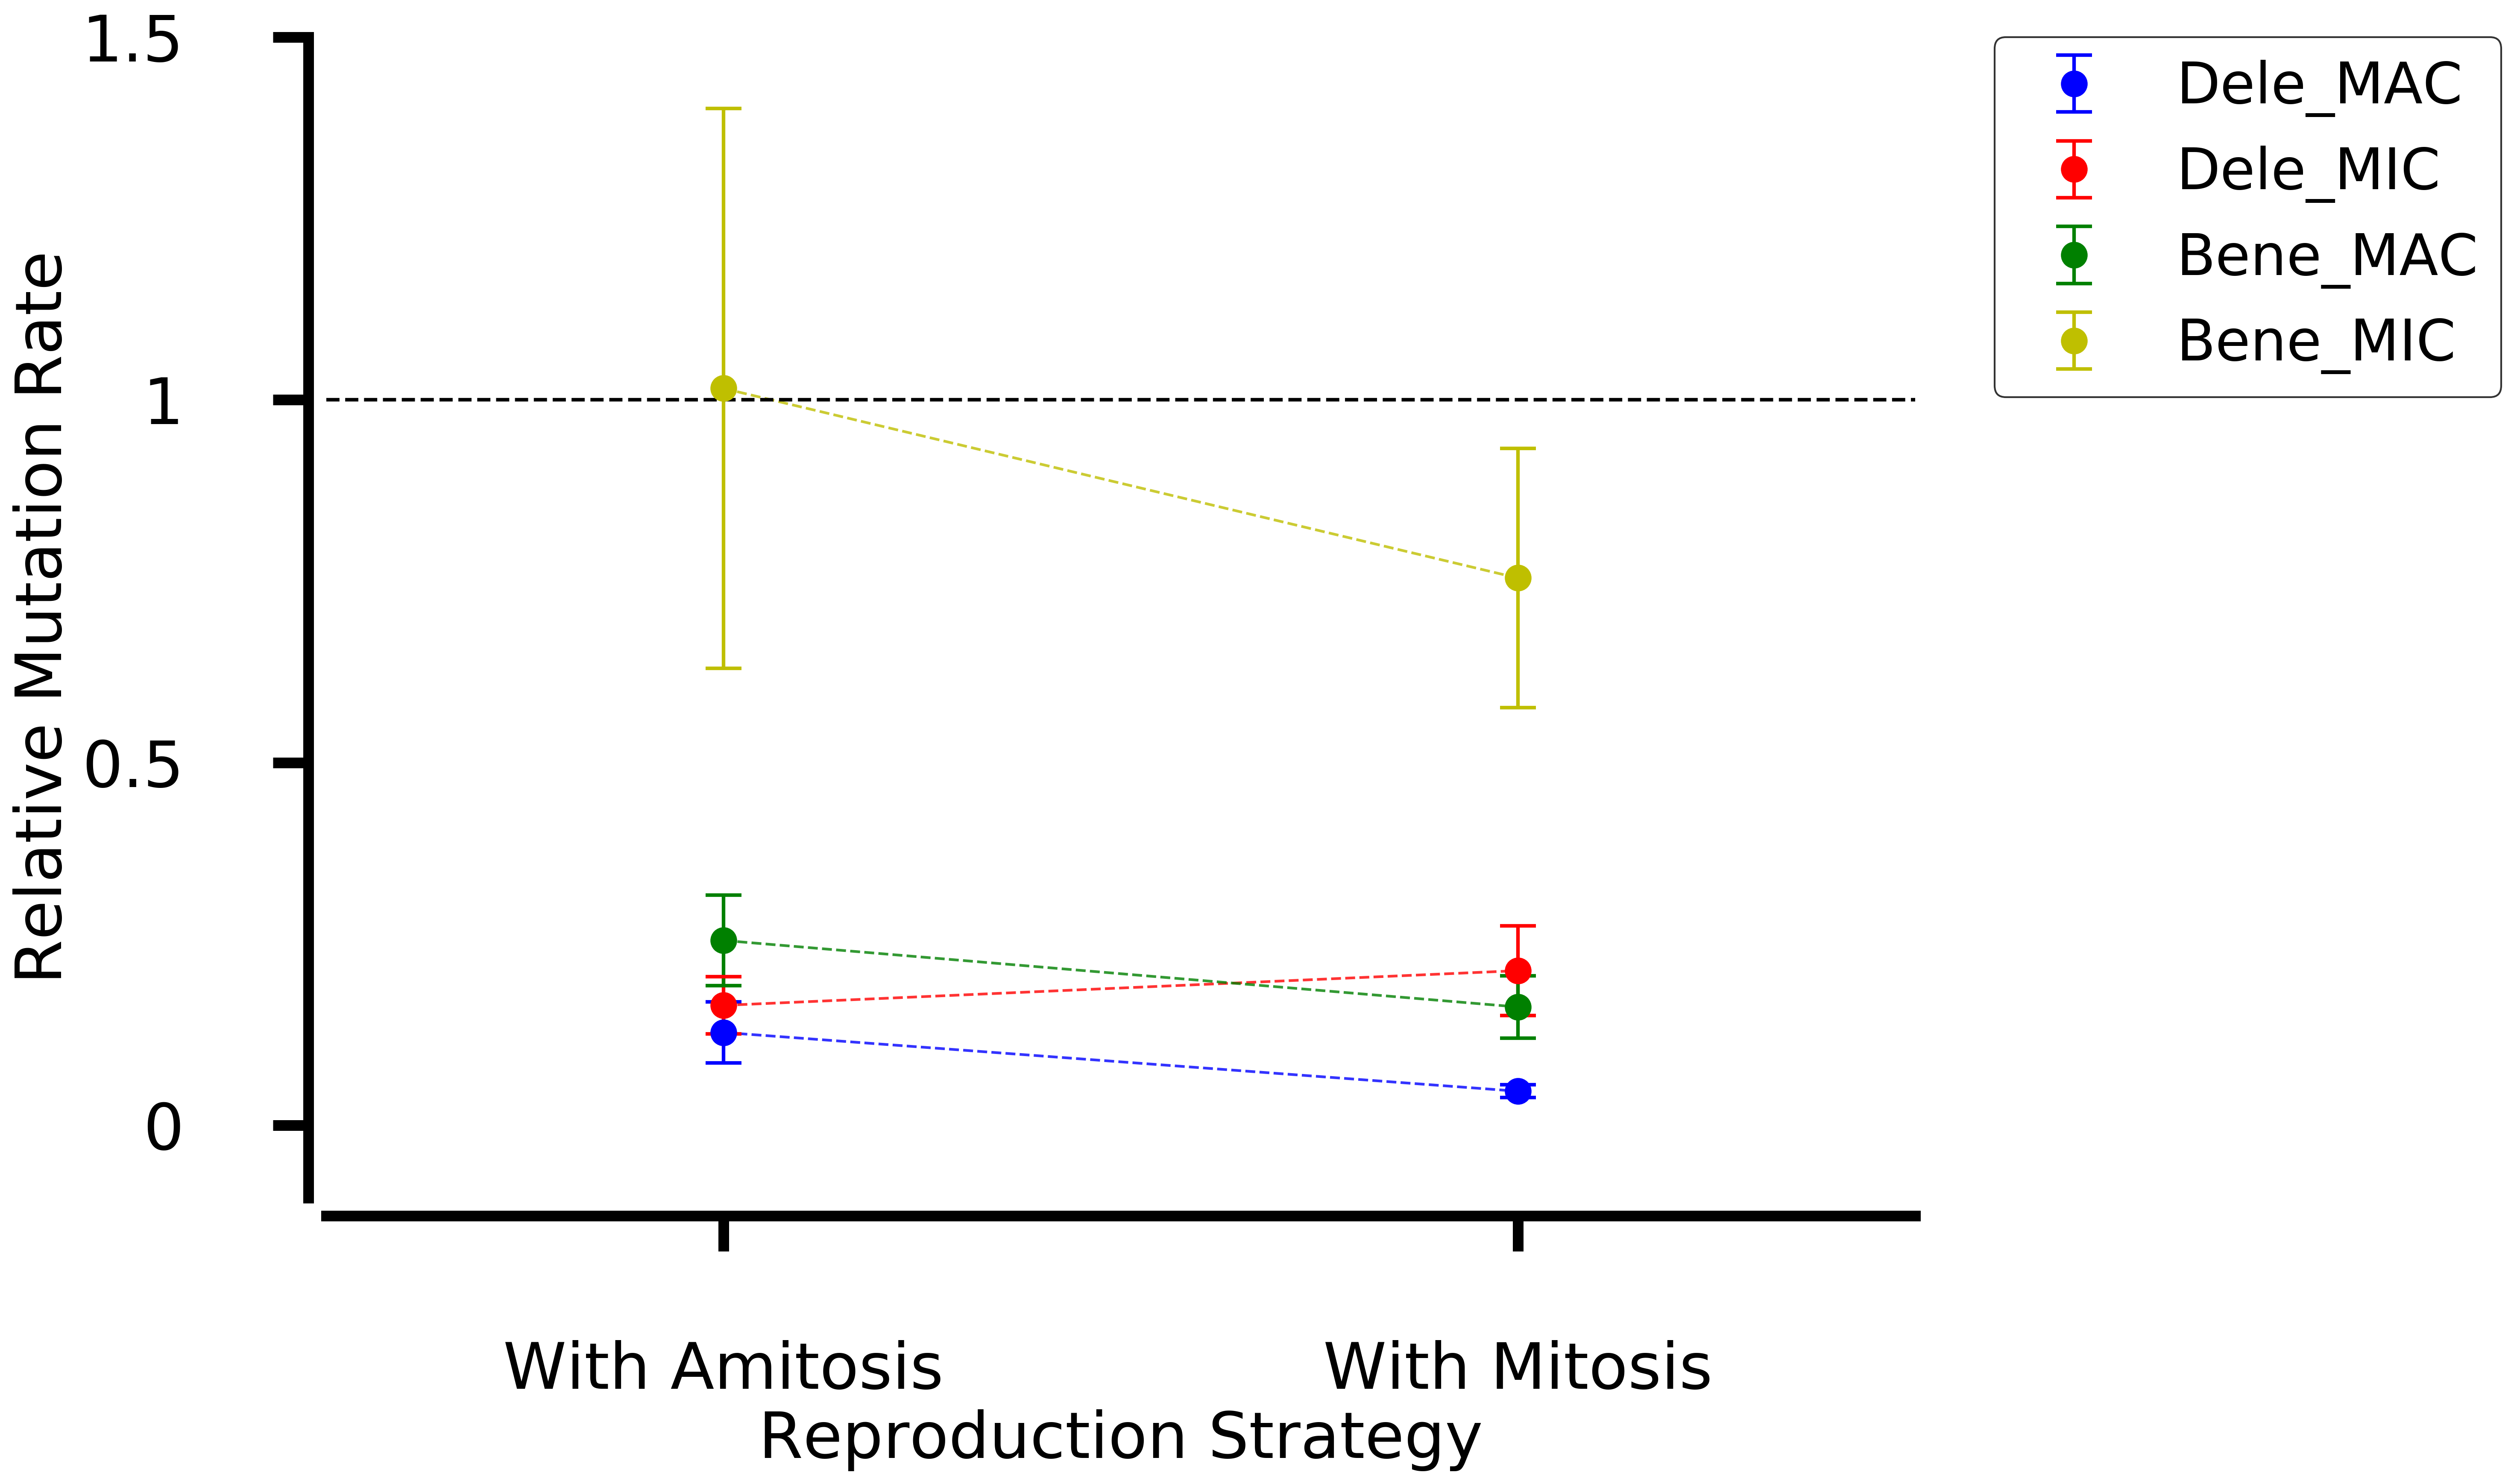

In [43]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_ylim(-0.1, 1.5)
ax.set_xlim(0.5,2.5)


x = [1,2]

a = dele_og_sm_mu_mean
error_a = 1.98* np.array(dele_og_sm_mu_std)/((100)**0.5)


b = dele_og_gm_mu_mean
error_b = 1.98* np.array(dele_og_gm_mu_std)/((100)**0.5)


c = bene_og_sm_mu_mean
print 'c', c
error_c = 1.98* np.array(bene_og_sm_mu_std)/((100)**0.5)


d = bene_og_gm_mu_mean
error_d = 1.98* np.array(bene_og_gm_mu_std)/((100)**0.5)


ax.set_xlabel('Reproduction Strategy', fontsize =36)
ax.set_ylabel('Relative Mutation Rate', fontsize =36)


ax.errorbar(x, a, yerr = error_a, label = 'Dele_MAC', fmt='o', color = 'b', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,a, ls = '--', color = 'b', alpha = 0.8)

ax.errorbar(x, b, yerr = error_b, label = 'Dele_MIC', fmt='o',color = 'r', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,b,ls = '--', color = 'r', alpha = 0.8)

ax.errorbar(x, c, yerr = error_c, label = 'Bene_MAC', fmt='o', color = 'g', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,c, ls = '--', color = 'g', alpha = 0.8)

ax.errorbar(x, d, yerr = error_d, label = 'Bene_MIC', fmt='o',color = 'y', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,d,ls = '--', color = 'y', alpha = 0.8)




plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =32)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')



ax.set_xticks([1, 2]) # choose which x locations to have ticks
# ax.set_xticklabels(['Both Amitosis', 'Both Mitosis', 'Fit Amito_Mod Mito', 'Fit Mito_Mod Amito'], rotation = 270) # set the labels to display at those ticks
ax.set_xticklabels(['With Amitosis', 'With Mitosis']) # set the labels to display at those ticks


ax.set_yticks([0, 0.5, 1, 1.5]) # choose which x locations to have ticks
# # ax.set_xticklabels(['Both Amitosis', 'Both Mitosis', 'Fit Amito_Mod Mito', 'Fit Mito_Mod Amito'], rotation = 270) # set the labels to display at those ticks
ax.set_yticklabels([0, 0.5, 1, 1.5]) # set the labels to display at those ticks


# plt.legend(loc='upper right', frameon=False, prop={'size':29})


plt.show()